# Imports

In [ ]:
import numpy as np 
import pandas as pd
from mggp import MGGP
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# from tensorflow.keras.models import load_model

# Functions

In [ ]:
def load_data(file_path, output_features, folder, filter=None, tire=None):  
    df = pd.read_csv(file_path)
    if 'Initial_Time' in df.columns and 'Final_Time' in df.columns:
        df.drop(columns=['Initial_Time', 'Final_Time'], inplace=True)
    # df = remove_window_with_noise(df, folder)
    
    if 'Ax' in df.columns:
        df.drop(columns=['Ax', 'Ay'], inplace=True)
    # df.drop(columns=["Fx_F", "Fx_R", "Fz_F", "Fz_R"], inplace=True)
    # df.drop(columns=["Fz_F", "Fz_R"], inplace=True)

    if tire is not None:
        df = df[df['Pneu'] == tire]        
        # df.drop(columns=['Pneu', 'Fx', 'Fz'], inplace=True)
        df.drop(columns=['Pneu'], inplace=True)
    
    if filter is not None:
        df = df.filter(regex=filter)

    X = df[[c for c in df.columns if c not in ['Fx', 'Fy', 'Fz']]].values
    y = df[['Fx', 'Fy', 'Fz']].values/1000 # Normalizado de N para kN
    
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

        
    return X, y, x_scaler, y_scaler

# Train MGGP Classifier

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
OUTPUT_FEATURES = 3

df = pd.read_csv('smart tire/Global_data_PVDF.csv')
df = df.dropna(axis=1)
columns_with_infinity = df.columns[df.isin([np.inf, -np.inf]).any()]
df = df.drop(columns=columns_with_infinity)

X = df.iloc[:, :-1]  
y = df.iloc[:, -1]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if len(y_train.values.shape):
    y_train = to_categorical(y_train, num_classes=max(y_train.values)+1)

if len(y_test.values.shape):
    y_test = to_categorical(y_test, num_classes=max(y_test.values)+1)
    
# for i in range(10):
mggp = MGGP(
            inputs=X_train.values,
            outputs=y_train,
            validation=(X_test.values, y_test),
            problem_type='classification',
            nDelays=1,
            classification_metric='accuracy',
            generations=250,
            populationSize=100,
            evaluationMode="RMSE",
            evaluationType='INSTANT',
            evaluationTypeTest='INSTANT',
            nTerms=20,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            # pruning_probability=0.5,
            # pruning_tolerance= 1e5, 
            # filename = f"mggp_models_classification/mggp_classifier{i}.pkl",
            filename = f"mggp_models_classification/test.pkl",
            mode="FIR"
            )

mggp.run()

2026-04-08 10:24:20.328447: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 10:24:20.329656: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 10:24:20.349306: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 10:24:20.349328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 10:24:20.349811: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

System Mode: FIR. N° Inputs: 16. N° Outputs: 8
Input Samples: 3197. Output Samples: 3197



Evaluating Initial Population: 100%|██████████| 100/100 [00:06<00:00, 16.27it/s]


   	     	                fitness                 
   	     	----------------------------------------
gen	evals	min     	avg     	max     
1  	100  	0.225594	0.269515	0.373592


Evaluating Population:  57%|█████▋    | 50/87 [00:03<00:02, 15.96it/s]


KeyboardInterrupt: 

In [19]:
from sklearn.metrics import accuracy_score
mggp_accuracies = []
for i in range(10):
    folder = "Job1_2023_07_28_16_41_10_Mix"
    path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
    u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

    save_model =  f"mggp_models_classification/mggp_classifier{i}.pkl"
    mggp = MGGP(inputs=u_train,
                outputs=y_train,
                mode="FIR",
                filename=save_model)
    
    df = pd.read_csv('smart tire/Global_data_PVDF.csv')
    df = df.dropna(axis=1)
    columns_with_infinity = df.columns[df.isin([np.inf, -np.inf]).any()]
    df = df.drop(columns=columns_with_infinity)

    X = df.iloc[:, :-1]  
    y = df.iloc[:, -1]  

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if len(y_train.values.shape):
        y_train = to_categorical(y_train, num_classes=max(y_train.values)+1)

    if len(y_test.values.shape):
        y_test = to_categorical(y_test, num_classes=max(y_test.values)+1)
    
    args = (y_test, X_test.values) 
    loaded_model = mggp.load_model()
    loaded_model._logistic_model = True
    y_pred, y_true = loaded_model.predict_classes('INSTANT', *args)
    
    mggp_accuracies.append(accuracy_score(y_true, y_pred))

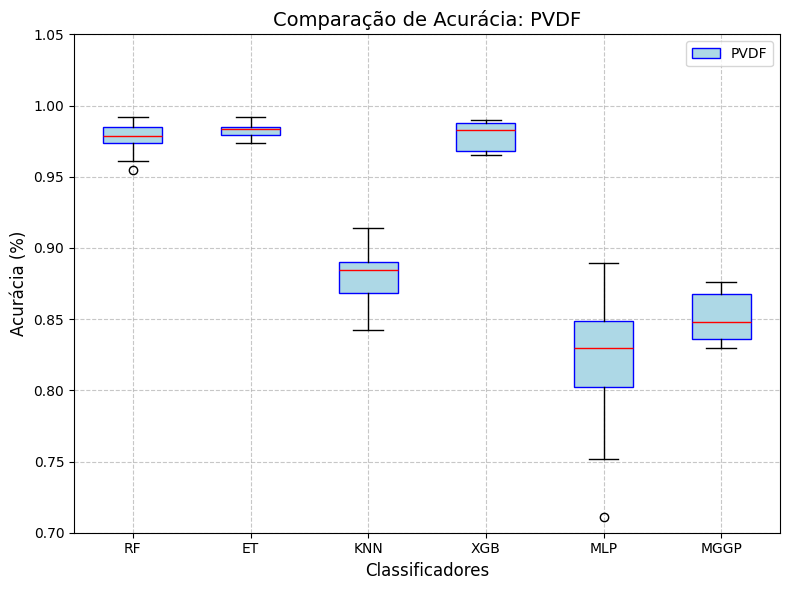

In [ ]:
all_scores_pvdf = {
    'RF': [0.95491803, 0.97336066, 0.97540984, 0.96106557, 0.98565574, 0.98360656, 0.99180328, 0.9795082, 0.97745902, 0.98770492],
    'ET': [0.98360656, 0.97745902, 0.97336066, 0.97336066, 0.98770492, 0.98565574, 0.98360656, 0.98360656, 0.98360656, 0.99180328],
    'KNN': [0.86065574, 0.8647541, 0.84221311, 0.87909836, 0.88729508, 0.90983607, 0.88114754, 0.88729508, 0.89139344, 0.91393443],
    'XGB': [0.96516393, 0.97131148, 0.96721311, 0.96516393, 0.98770492, 0.9795082, 0.9897541, 0.98770492, 0.98565574, 0.9897541],
    'MLP': [0.81147541, 0.83401639, 0.79918033, 0.85245902, 0.82581967, 0.85655738, 0.75204918, 0.83811475, 0.71106557, 0.88934426],
    'MGGP': mggp_accuracies
}

labels = ['RF', 'ET', 'KNN', 'XGB', 'MLP', 'MGGP']
pvdf_scores = [all_scores_pvdf['RF'], 
               all_scores_pvdf['ET'], 
               all_scores_pvdf['KNN'], 
               all_scores_pvdf['XGB'], 
               all_scores_pvdf['MLP'],
               all_scores_pvdf['MGGP'],
               ]

plt.figure(figsize=(8, 6))

# positions_accx = np.arange(len(labels)) * 2 - 0.3  # Posições deslocadas para a esquerda
# box1 = plt.boxplot(accx_scores, positions=positions_accx, widths=0.5, patch_artist=True,
#                    boxprops=dict(facecolor='lightblue', color='blue'),
#                    medianprops=dict(color='red'))

positions_pvdf = np.arange(len(labels))   # Posições deslocadas para a direita
box2 = plt.boxplot(pvdf_scores, positions=positions_pvdf, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red'))

plt.title('Comparação de Acurácia: PVDF', fontsize=14)
plt.xlabel('Classificadores', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
# plt.legend([box1["boxes"][0], box2["boxes"][0]], ['AccX', 'PVDF'], loc='upper right')
plt.legend([box2["boxes"][0]], ['PVDF'], loc='upper right')
# Ajustar limites do eixo Y para melhor visualização
plt.ylim(0.7, 1.05)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('Boxplot_Comparison_PVDF.png', bbox_inches='tight', dpi=300)
plt.show()

## Load Classifier

In [43]:
folder = "Job1_2023_07_28_16_41_10_Mix"
# path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_medias_R_F_with_Fz_25.csv"
path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
# u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, filter='_F$')
u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

save_model = "mggp_models_classification/mggp_classifier4.pkl"
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            filename=save_model)

loaded_model = mggp.load_model()

print(mggp.simplify_model(loaded_model))
# print(loaded_model)

Output 1:
3.80132e-01 * 
1.17873e-01 * u12[i-1] +
5.79008e-01 * u5[i-1] * u7[i-1] +
1.70210e+00 * u3[i-1] +
-9.80848e-02 * u8[i-1] +
-1.96379e-02 * u1[i-1] * u15[i-1] +
-6.22994e+00 * u14[i-1] * u9[i-1] +
-3.77954e-01 * u3[i-1] * u13[i-1] * u3[i-1] * u9[i-1] +
-1.47960e-01 * u13[i-1] +
-2.25446e-03 * u10[i-1] * u10[i-1] +
-2.39738e-01 * u11[i-1] * u5[i-1] +
-3.20716e-01 * u9[i-1] +
3.36282e-01 * u6[i-1] * u14[i-1] * u7[i-1] * u8[i-1] +
8.84707e-04 * u10[i-1] * u10[i-1] * u16[i-1] +
-6.58955e-02 * u7[i-1] +
-1.37601e-05 * u12[i-1] * u12[i-1] * u10[i-1] +
5.75543e-04 * u6[i-1] * u6[i-1] +
5.89589e-02 * u11[i-1] +
Output 2:
1.16008e+00 * 
2.57569e-01 * u12[i-1] +
2.16789e-01 * u12[i-1] * u4[i-1] * u4[i-1] * u4[i-1] +
-9.30237e-02 * u10[i-1] +
-3.93976e-02 * u1[i-1] * u1[i-1] +
7.09207e-01 * u4[i-1] * u4[i-1] +
5.35112e+00 * u10[i-1] * u14[i-1] +
-4.75763e-01 * u13[i-1] +
6.38153e-02 * u10[i-1] * u13[i-1] +
-2.82268e-01 * u9[i-1] +
-4.73976e+00 * u7[i-1] * u2[i-1] * u3[i-1] * u10[i-1] +
-8